# SPY and OIL EDA

In [ ]:

import yfinance as yf

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, os
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

from arch import arch_model
from arch.univariate.base import DataScaleWarning

plt.rcParams.update({"figure.dpi":150,"font.size":10,"axes.titlesize":12,
    "axes.labelsize":10,"figure.facecolor":"white","axes.facecolor":"white",
    "axes.grid":True,"grid.alpha":0.3})


In [ ]:
DATA = "./data"
OUT="./eda_outputs"; os.makedirs(OUT, exist_ok=True)


In [59]:
%matplotlib inline

In [ ]:
## Download SPY, OIL Prices

spy = yf.download("SPY", start="2000-01-01", end="2025-12-31")
oil = yf.download("CL=F", start="2000-01-01", end="2025-12-31")
spy.to_csv(f"{OUT}/SPY_data.csv")
oil.to_csv(f"{OUT}/OIL_data.csv")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:

# ── 1. LOAD ──
print("="*65+"\nLOADING DATA\n"+"="*65)
spy_df=pd.read_csv("SPY_data.csv",skiprows=[1,2],parse_dates=["Price"],index_col="Price")
oil_df=pd.read_csv("OIL_data.csv",skiprows=[1,2],parse_dates=["Price"],index_col="Price")
spy_df.index.name="Date"; oil_df.index.name="Date"
spy_prices=spy_df["Close"].astype(float).dropna()
oil_prices=oil_df["Close"].astype(float).dropna()
print(f"SPY: {len(spy_prices)} days  [{spy_prices.index[0].date()} -> {spy_prices.index[-1].date()}]")
print(f"OIL: {len(oil_prices)} days  [{oil_prices.index[0].date()} -> {oil_prices.index[-1].date()}]")

neg_oil=oil_prices[oil_prices<=0]
if len(neg_oil)>0: print(f"\nOil prices <= 0 on {len(neg_oil)} days:"); print(neg_oil)

spy_ret=np.log(spy_prices/spy_prices.shift(1)).dropna()*100
oil_ret=np.log(oil_prices/oil_prices.shift(1)).dropna()*100
oil_ret=oil_ret.replace([np.inf,-np.inf],np.nan).dropna()
print(f"\nSPY returns: {len(spy_ret)} obs\nOIL returns: {len(oil_ret)} obs")


LOADING DATA
SPY: 6538 days  [2000-01-03 -> 2025-12-30]
OIL: 6366 days  [2000-08-23 -> 2025-12-30]

Oil prices <= 0 on 1 days:
Date
2020-04-20   -37.630001
Name: Close, dtype: float64

SPY returns: 6537 obs
OIL returns: 6363 obs


## 1. Descriptive Stats

In [136]:

# ── 2. DESCRIPTIVE STATS ──
def desc(s,nm):
    jb,jp=stats.jarque_bera(s)
    return {"Series":nm,"N":len(s),"Mean":s.mean(),"Median":s.median(),
            "Std":s.std(),"Min":s.min(),"Max":s.max(),
            "Skew":stats.skew(s),"ExKurt":stats.kurtosis(s)}

print("\n"+"="*65+"\nDESCRIPTIVE STATISTICS (Prices, %)\n"+"="*65)
sdf=pd.DataFrame([desc(spy_prices,"SPY"),desc(oil_prices,"OIL")]).set_index("Series")
print(sdf.to_string(float_format=lambda x:f"{x:.4f}"))
sdf.to_csv(f"{OUT}/descriptive_stats_prices.csv",float_format="%.6f")


print("\n"+"="*65+"\nDESCRIPTIVE STATISTICS (Daily Log Returns, %)\n"+"="*65)
sdf=pd.DataFrame([desc(spy_ret,"SPY"),desc(oil_ret,"OIL")]).set_index("Series")
print(sdf.to_string(float_format=lambda x:f"{x:.4f}"))
sdf.to_csv(f"{OUT}/descriptive_stats_log_returns.csv",float_format="%.6f")



DESCRIPTIVE STATISTICS (Prices, %)
           N     Mean   Median      Std      Min      Max   Skew  ExKurt
Series                                                                  
SPY     6538 196.4378 116.1530 152.9166  49.9446 690.3800 1.3349  0.8502
OIL     6366  64.6650  63.6750  24.5879 -37.6300 145.2900 0.1940 -0.5354

DESCRIPTIVE STATISTICS (Daily Log Returns, %)
           N   Mean  Median    Std      Min     Max    Skew  ExKurt
Series                                                             
SPY     6537 0.0308  0.0692 1.2221 -11.5886 13.5578 -0.2093 11.5261
OIL     6363 0.0188  0.1035 2.5804 -28.2206 31.9634 -0.0317 16.3429


## 2. Stationarity Tests

In [64]:

# ── 3. STATIONARITY ──
print("\n"+"="*65+"\nSTATIONARITY TESTS\n"+"="*65)
def station(s,nm):
    a_s,a_p,a_l,_,a_c,_=adfuller(s,autolag="AIC")
    k_s,k_p,k_l,k_c=kpss(s,regression="c",nlags="auto")
    print(f"\n--- {nm} ---")
    print(f"  ADF: stat={a_s:.4f} p={a_p} -> {'STATIONARY' if a_p<0.05 else 'NON-STATIONARY'}")
    print(f"  KPSS: stat={k_s:.4f} p={k_p} -> {'STATIONARY' if k_p>0.05 else 'NON-STATIONARY'}")
    return {"Series":nm,"ADF_stat":a_s,"ADF_p":a_p,"KPSS_stat":k_s,"KPSS_p":k_p}
st=[station(spy_ret,"SPY Returns"),station(oil_ret,"OIL Returns"),
    station(spy_prices,"SPY Prices"),station(oil_prices,"OIL Prices")]
pd.DataFrame(st).to_csv(f"{OUT}/stationarity_tests.csv",index=False,float_format="%.6f")



STATIONARITY TESTS

--- SPY Returns ---
  ADF: stat=-20.2158 p=0.0 -> STATIONARY
  KPSS: stat=0.4263 p=0.06582869444965399 -> STATIONARY

--- OIL Returns ---
  ADF: stat=-14.4467 p=7.209706334238218e-27 -> STATIONARY
  KPSS: stat=0.0456 p=0.1 -> STATIONARY

--- SPY Prices ---
  ADF: stat=3.5983 p=1.0 -> NON-STATIONARY
  KPSS: stat=10.0959 p=0.01 -> NON-STATIONARY

--- OIL Prices ---
  ADF: stat=-2.8948 p=0.045952544909079136 -> STATIONARY
  KPSS: stat=2.0997 p=0.01 -> NON-STATIONARY


In [67]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## 3. Prices Time Series Plot

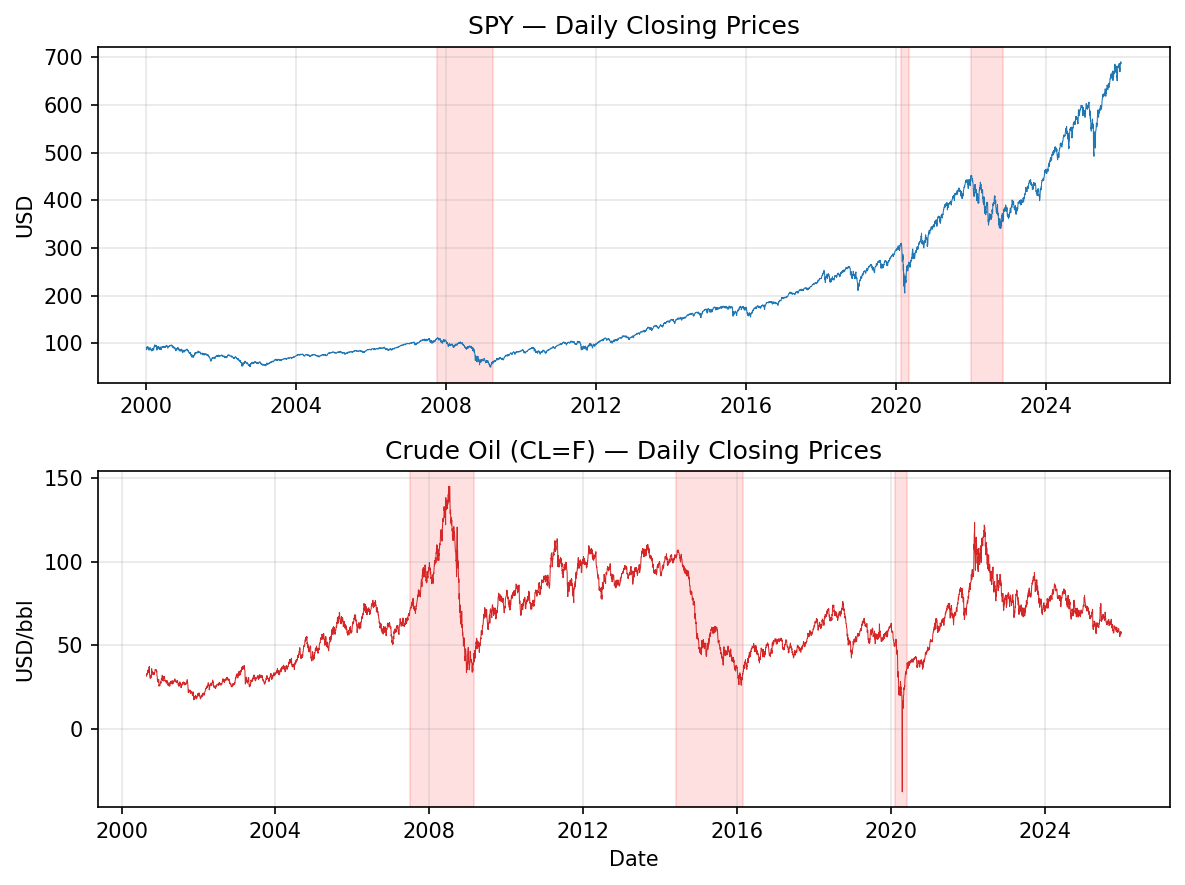

  fig1_prices.png


In [114]:
# ── 6. FIGURES ──
cr_spy=[("2007-10-01","2009-03-31"),("2020-02-15","2020-04-30"),("2022-01-01","2022-10-31")]
cr_oil=[("2007-07-01","2009-02-28"),("2014-06-01","2016-02-28"),("2020-02-15","2020-05-31")]

# FIG1 prices
fig,ax=plt.subplots(2,1,figsize=(8,6))
ax[0].plot(spy_prices.index,spy_prices.values,color="#1f77b4",lw=0.5)
ax[0].set_title("SPY — Daily Closing Prices");ax[0].set_ylabel("USD")
for s,e in cr_spy: ax[0].axvspan(pd.Timestamp(s),pd.Timestamp(e),alpha=0.12,color="red")

ax[1].plot(oil_prices.index,oil_prices.values,color="#d62728",lw=0.5)
ax[1].set_title("Crude Oil (CL=F) — Daily Closing Prices");ax[1].set_ylabel("USD/bbl")
for s,e in cr_oil: ax[1].axvspan(pd.Timestamp(s),pd.Timestamp(e),alpha=0.12,color="red")
ax[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig(f"{OUT}/fig1_prices.png",bbox_inches="tight",dpi=150)
plt.show()
print("  fig1_prices.png")

## 4. Prices ACF, PACF Plots

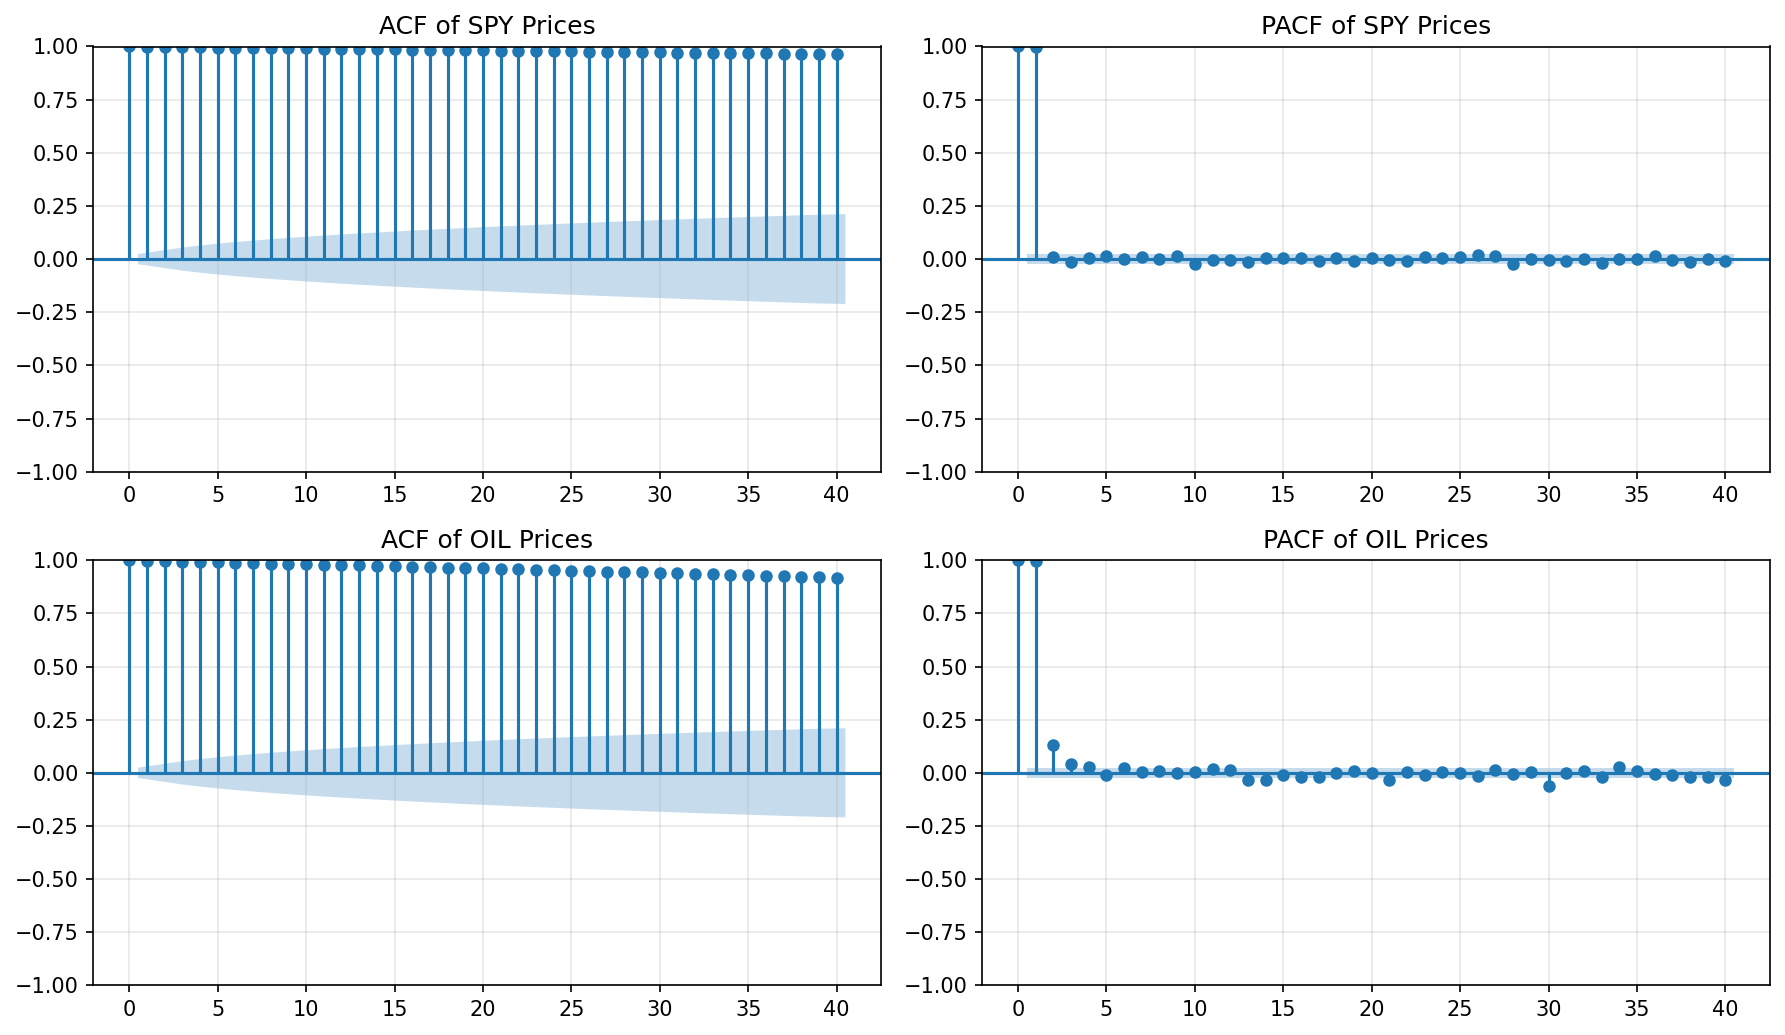

  fig2_prices_acf_pacf.png


In [115]:
## ACF, PACF plots of SPY and OIL price time series
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(spy_prices, lags=40, ax=axes[0, 0], title='ACF of SPY Prices')
plot_pacf(spy_prices, lags=40, ax=axes[0, 1], title='PACF of SPY Prices')
plot_acf(oil_prices, lags=40, ax=axes[1, 0], title='ACF of OIL Prices')
plot_pacf(oil_prices, lags=40, ax=axes[1, 1], title='PACF of OIL Prices')
plt.tight_layout()
plt.savefig(f"{OUT}/fig2_prices_acf_pacf.png", dpi=150, bbox_inches='tight')
plt.show()
print("  fig2_prices_acf_pacf.png")



## 5. Best ARIMA(p, d, q) fit on Prices

In [35]:
print('Fitting SPY ARIMA...')

best_aic = np.inf; best_order = None
for d in [1, 2]:
    for p in range(0, 8):
        for q in range(0, 8):
            if p == 0 and q == 0: continue
            try:
                fit = ARIMA(spy_prices, order=(p, d, q)).fit()
                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_order = (p, d, q)
            except: pass
print(f'SPY best: ARIMA{best_order}, AIC={best_aic:.2f}')

Fitting weekly ARIMA...
Weekly: ARIMA(7, 1, 7), AIC=31196.11


In [36]:
best_aic = np.inf; best_order = None; count = 0
for d in [1, 2]:
    for p in range(0, 8):
        for q in range(0, 8):
            if p == 0 and q == 0: continue
            count += 1
            try:
                fit = ARIMA(oil_prices, order=(p, d, q)).fit()
                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_order = (p, d, q)
                    print(f'  New best: ARIMA{best_order}, AIC={best_aic:.2f} (model #{count})')
            except: pass
            if count % 20 == 0:
                print(f'  ... {count} models tested')

print(f'OIL best: ARIMA{best_order}, AIC={best_aic:.2f}')

  New best: ARIMA(0, 1, 1), AIC=25309.47 (model #1)
  New best: ARIMA(0, 1, 2), AIC=25305.79 (model #2)
  New best: ARIMA(0, 1, 5), AIC=25305.47 (model #5)
  New best: ARIMA(1, 1, 1), AIC=25304.95 (model #9)
  ... 20 models tested
  New best: ARIMA(4, 1, 4), AIC=25302.50 (model #36)
  New best: ARIMA(4, 1, 6), AIC=25299.99 (model #38)
  ... 40 models tested
  New best: ARIMA(5, 1, 6), AIC=25297.75 (model #46)
  New best: ARIMA(6, 1, 6), AIC=25297.39 (model #54)
  ... 60 models tested
  ... 80 models tested
  ... 100 models tested
  ... 120 models tested
OIL best: ARIMA(6, 1, 6), AIC=25297.39


In [37]:
# Fit ARIMA models with best parameters
# Weekly: ARIMA(6,2,6), Daily: ARIMA(4,1,3)

# --- SPY ARIMA(7,1,7) ---
print("=" * 60)
print("SPY ARIMA(7,1,7) Model Summary")
print("=" * 60)
spy_arima = ARIMA(spy_prices.values, order=(7, 1, 7))
spy_arima_fit = spy_arima.fit()
print(spy_arima_fit.summary())


print("\n" + "=" * 60)
print("OIL ARIMA(6,1,6) Model Summary")
print("=" * 60)
oil_arima = ARIMA(oil_prices.values, order=(6, 1, 6))
oil_arima_fit = oil_arima.fit()
print(oil_arima_fit.summary())


SPY ARIMA(7,1,7) Model Summary
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 6538
Model:                 ARIMA(7, 1, 7)   Log Likelihood              -15583.054
Date:                Sat, 14 Mar 2026   AIC                          31196.109
Time:                        23:34:39   BIC                          31297.887
Sample:                             0   HQIC                         31231.301
                               - 6538                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0960      0.075     -1.278      0.201      -0.243       0.051
ar.L2          0.1272      0.044      2.868      0.004       0.040       0.214
ar.L3         -0.3726

### 5.1 Residual and Squared Residual Analysis

In [39]:
spy_resid = spy_arima_fit.resid
oil_resid = oil_arima_fit.resid

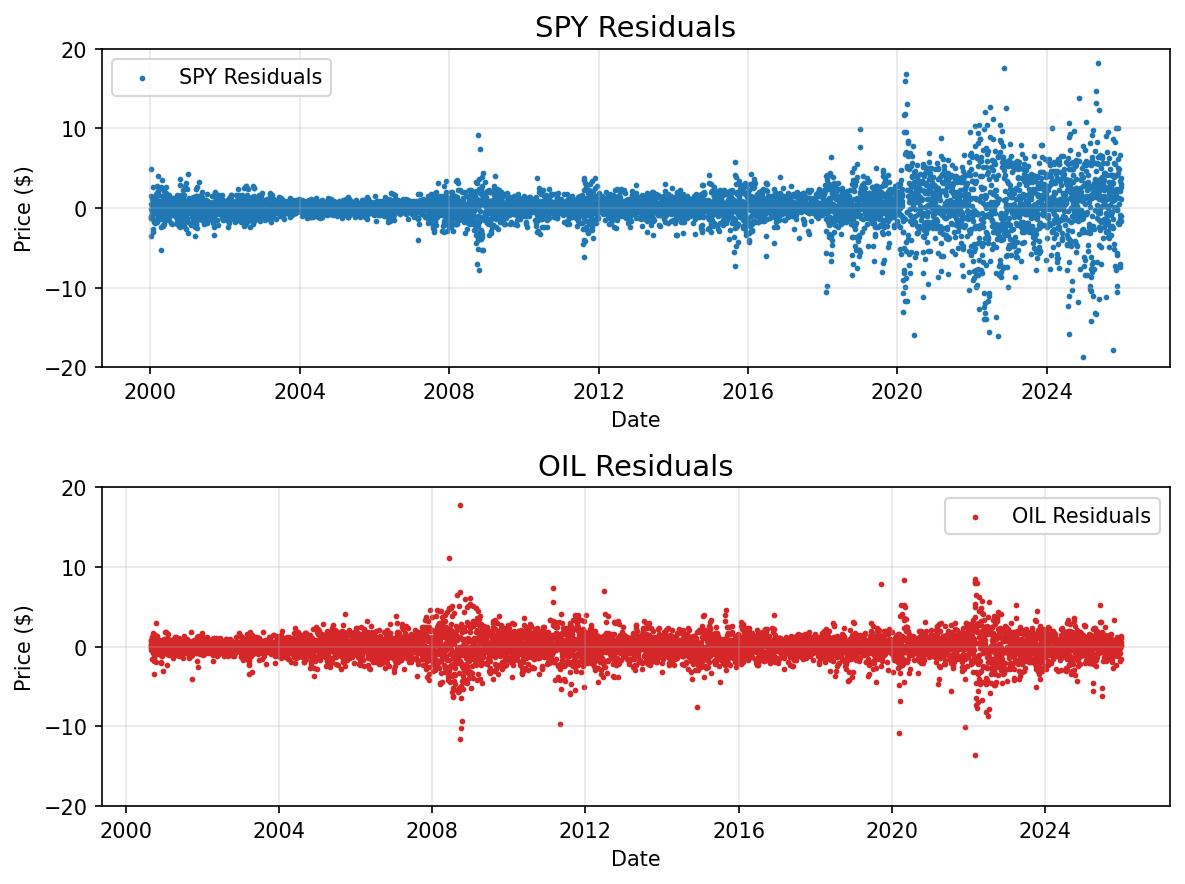

In [116]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].scatter(spy_prices.index, spy_resid, color='#1f77b4', s=3,label='SPY Residuals')
axes[0].set_title('SPY Residuals', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylim(-20, 20)
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(oil_prices.index, oil_resid, color='#d62728', s=3,label='OIL Residuals')
axes[1].set_title('OIL Residuals', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylim(-20, 20)
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT}/fig3_SPY_OIL_Residuals.png", dpi=150, bbox_inches='tight')
plt.show()

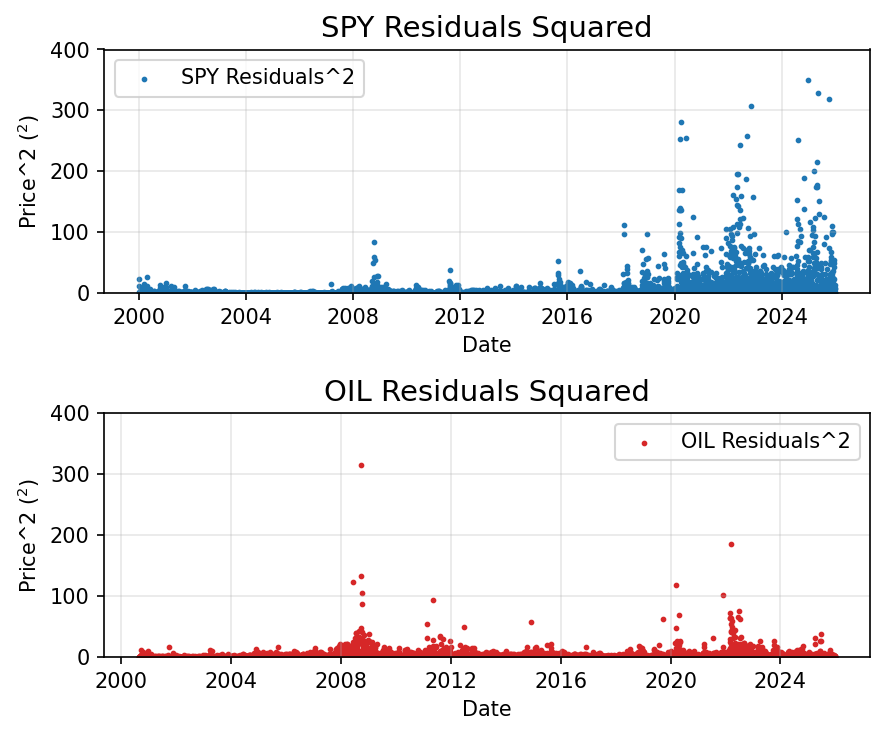

In [117]:
# scatter plots of squared residuals
fig, axes = plt.subplots(2, 1, figsize=(6, 5))
axes[0].scatter(spy_prices.index, spy_resid**2, color='#1f77b4', s=3,label='SPY Residuals^2')
axes[0].set_title('SPY Residuals Squared', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylim(0, 400)
axes[0].set_ylabel('Price^2 ($^2$)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(oil_prices.index, oil_resid**2, color='#d62728', s=3,label='OIL Residuals^2')
axes[1].set_title('OIL Residuals Squared', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylim(0, 400)
axes[1].set_ylabel('Price^2 ($^2$)')
axes[1].legend()        
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/fig4_SPY_OIL_Residuals_Squared.png", dpi=150, bbox_inches='tight')
plt.show()

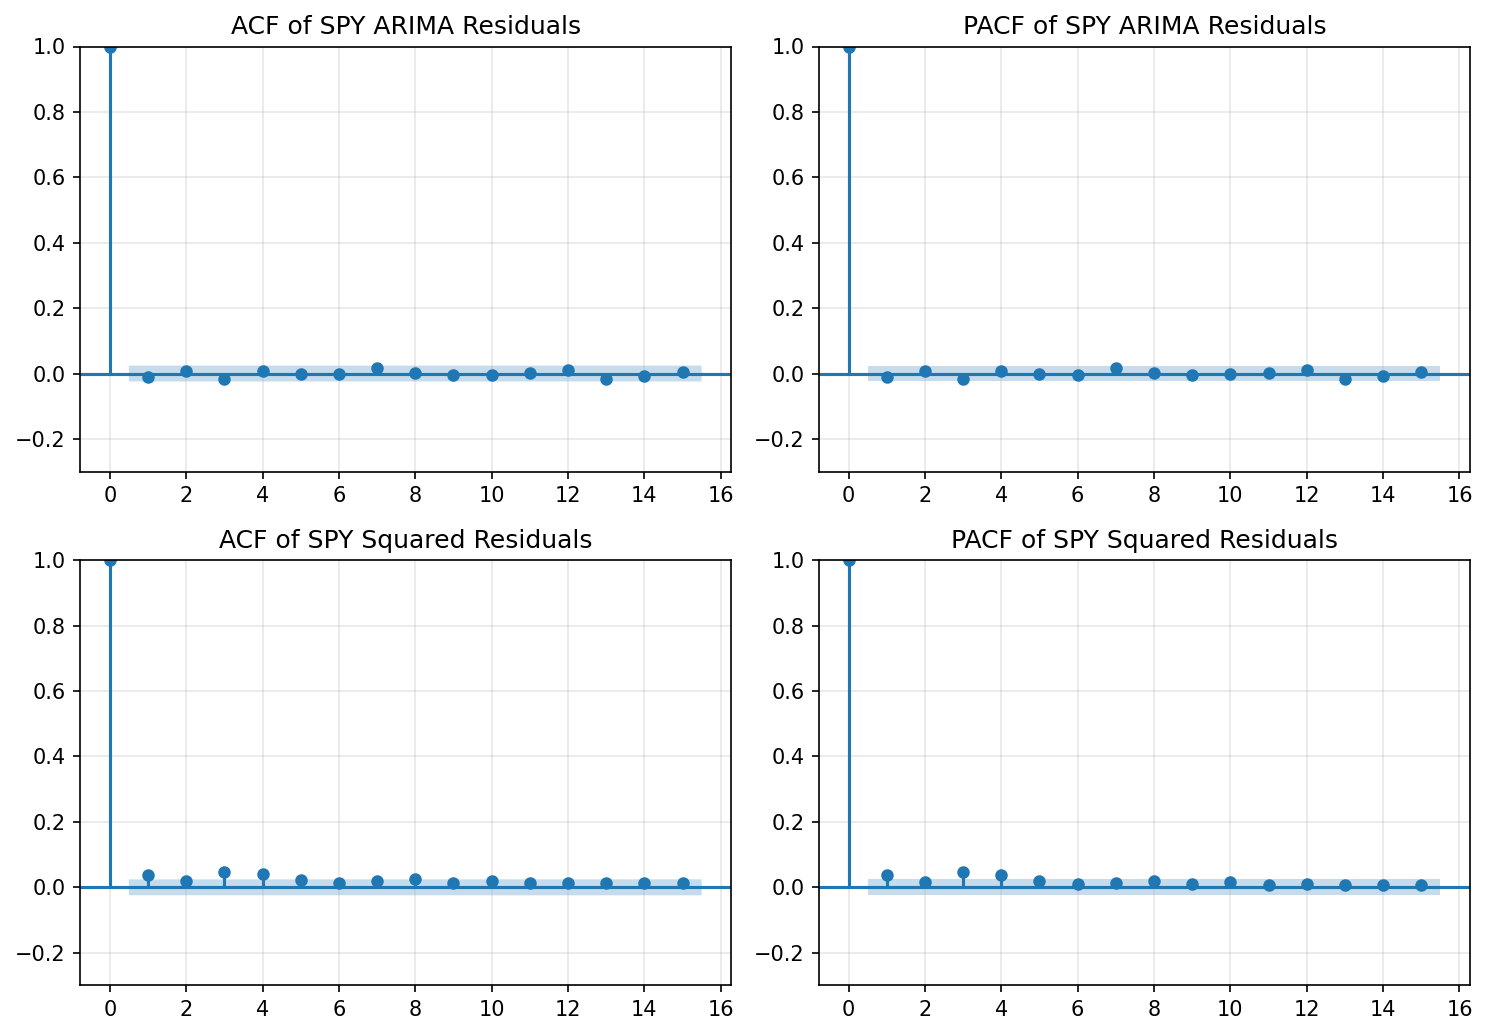

In [122]:

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# SPY residuals ACF/PACF
plot_acf(ax = axes[0, 0], x=spy_resid, lags=15, auto_ylims=False, title='ACF of SPY ARIMA Residuals')
plot_pacf(ax = axes[0, 1], x=spy_resid, lags=15, auto_ylims=False, title='PACF of SPY ARIMA Residuals')
axes[0, 0].set_ylim(-0.3, 1.0)
axes[0, 1].set_ylim(-0.3, 1.0)

# SPY squared residuals ACF/PACF
plot_acf(ax = axes[1, 0], x=spy_resid**2, lags=15, auto_ylims=False, title='ACF of SPY Squared Residuals')
plot_pacf(ax = axes[1, 1], x=spy_resid**2, lags=15, auto_ylims=False, title='PACF of SPY Squared Residuals')
axes[1, 0].set_ylim(-0.3, 1.0)
axes[1, 1].set_ylim(-0.3, 1.0)

plt.tight_layout()
plt.savefig(f"{OUT}/fig5_SPY_residuals_acf_pacf.png", dpi=150, bbox_inches='tight')
plt.show()


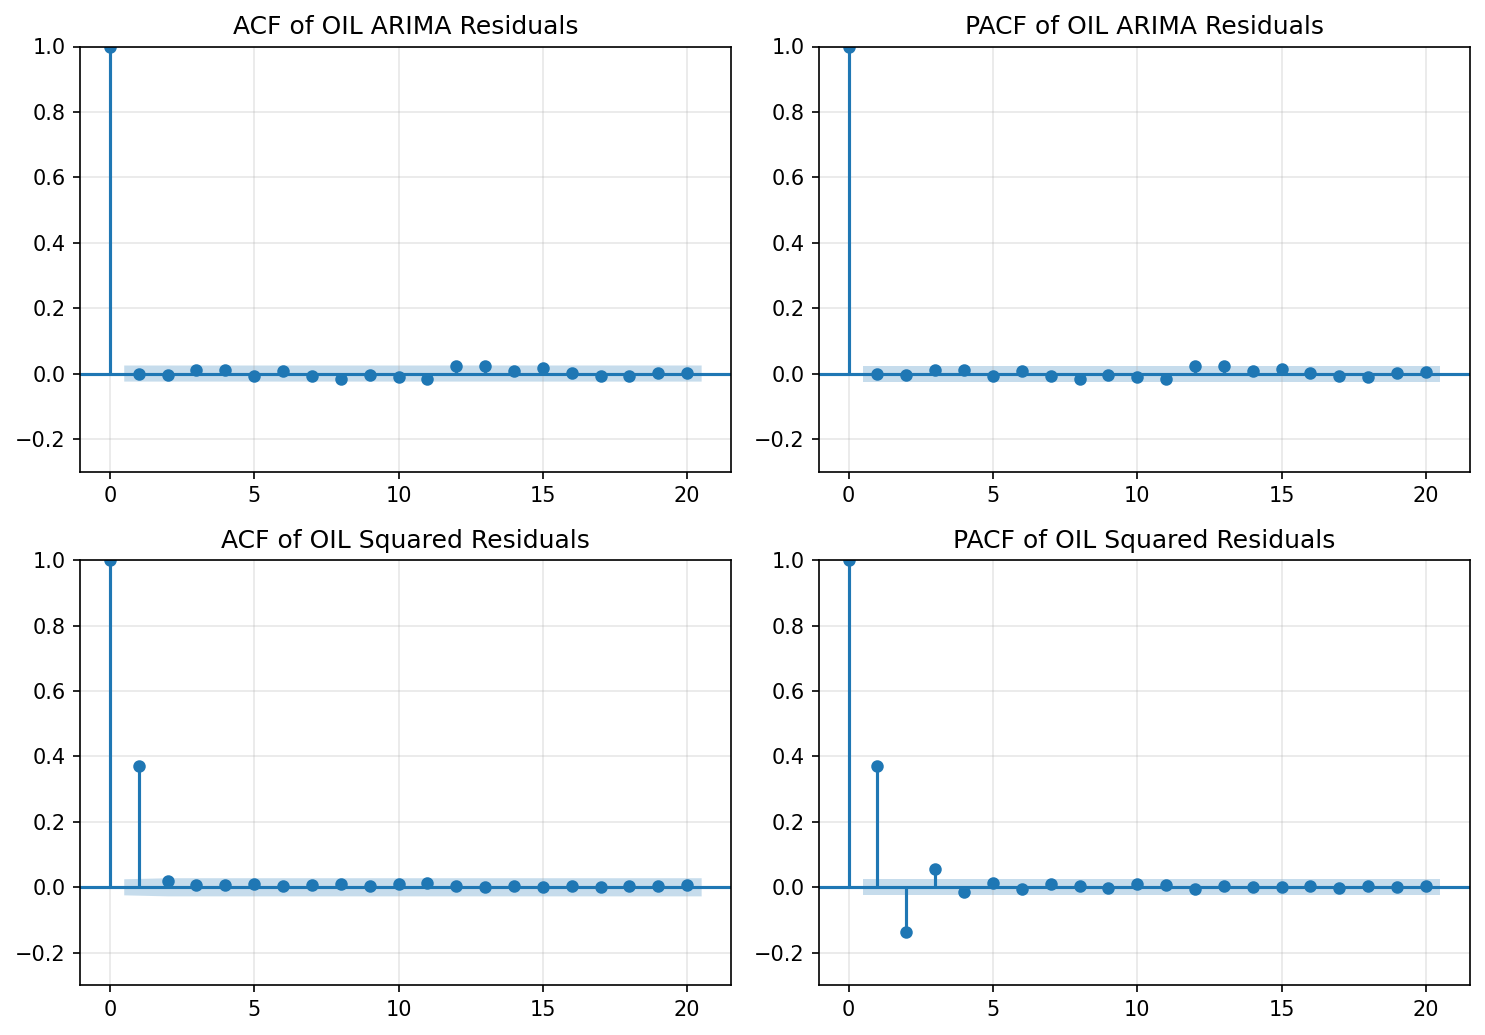

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# OIL residuals ACF/PACF
plot_acf(ax = axes[0, 0], x=oil_resid, lags=20, auto_ylims=False, title='ACF of OIL ARIMA Residuals')
plot_pacf(ax = axes[0, 1], x=oil_resid, lags=20, auto_ylims=False, title='PACF of OIL ARIMA Residuals')
axes[0, 0].set_ylim(-0.3, 1.0)
axes[0, 1].set_ylim(-0.3, 1.0)

# OIL squared residuals ACF/PACF
plot_acf(ax = axes[1, 0], x=oil_resid**2, lags=20, auto_ylims=False, title='ACF of OIL Squared Residuals')
plot_pacf(ax = axes[1, 1], x=oil_resid**2, lags=20, auto_ylims=False, title='PACF of OIL Squared Residuals')
axes[1, 0].set_ylim(-0.3, 1.0)
axes[1, 1].set_ylim(-0.3, 1.0)

plt.tight_layout()
plt.savefig(f"{OUT}/fig6_OIL_residuals_acf_pacf.png", dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Heteroskedasticity (Variance) Test

In [82]:
# Ljung-Box test for serial correlation in residuals (white noise test)
print("Ljung-Box Test for Residuals (White Noise):")
print("-" * 50)
print("SPY Residuals:")
lb_spy = acorr_ljungbox(spy_resid, lags=[10, 20, 30], return_df=True)
print(lb_spy)

print("\nOIL Residuals:")
lb_oil = acorr_ljungbox(oil_resid, lags=[10, 20, 30], return_df=True)
print(lb_oil)

# Ljung-Box test for squared residuals (heteroskedasticity / ARCH effects)
print("\n" + "=" * 50)
print("Ljung-Box Test for Squared Residuals (ARCH Effects / Heteroskedasticity):")
print("-" * 50)
print("SPY Squared Residuals:")
lb_spy_sq = acorr_ljungbox(spy_resid**2, lags=[10, 20, 30], return_df=True)
print(lb_spy_sq)

print("\nOIL Squared Residuals:")
lb_oil_sq = acorr_ljungbox(oil_resid**2, lags=[10, 20, 30], return_df=True)
print(lb_oil_sq)


Ljung-Box Test for Residuals (White Noise):
--------------------------------------------------
SPY Residuals:
      lb_stat  lb_pvalue
10   5.670603   0.842137
20  10.604172   0.955849
30  28.949778   0.520236

OIL Residuals:
      lb_stat  lb_pvalue
10   5.495014   0.855758
20  16.905397   0.659108
30  41.994458   0.071652

Ljung-Box Test for Squared Residuals (ARCH Effects / Heteroskedasticity):
--------------------------------------------------
SPY Squared Residuals:
      lb_stat     lb_pvalue
10  51.459264  1.436625e-07
20  60.947742  5.075470e-06
30  72.075117  2.546502e-05

OIL Squared Residuals:
       lb_stat      lb_pvalue
10  876.824143  6.185100e-182
20  878.817206  2.525160e-173
30  887.966440  2.075598e-167


**Squared Residual Test shows HHeteroskedasticity -> Need for variance modelling**

## 6. Log Returns

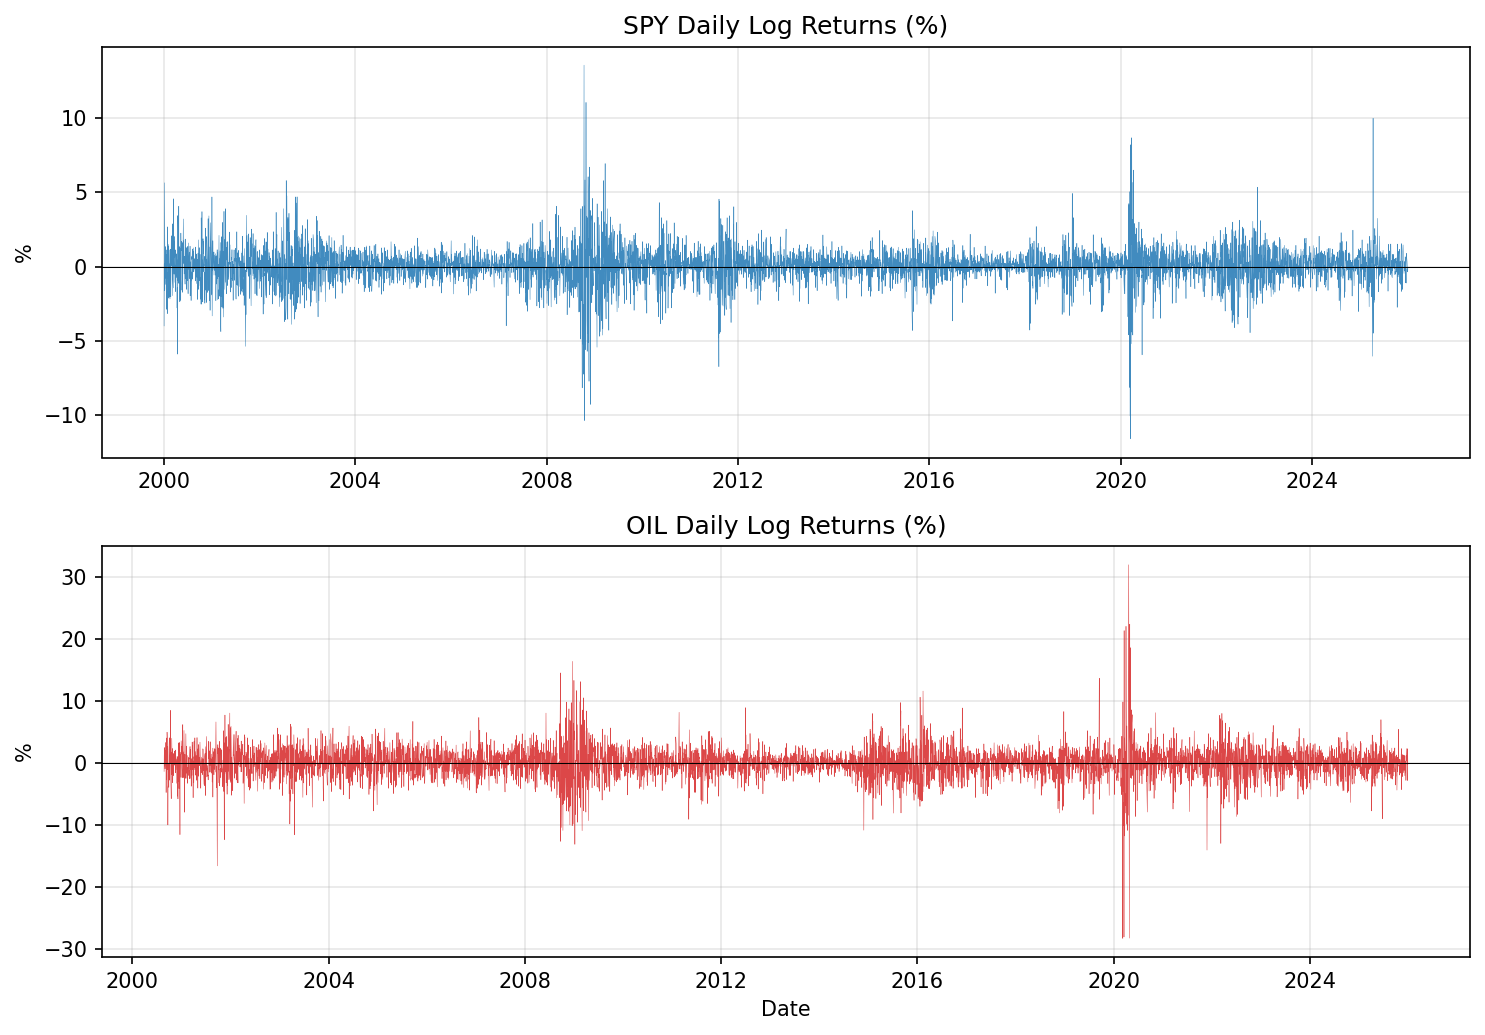

  fig7_SPY_OIL_returns_time_series.png


In [124]:

# FIG2 returns
fig,ax=plt.subplots(2,1,figsize=(10,7))
ax[0].plot(spy_ret.index,spy_ret.values,color="#1f77b4",lw=0.25,alpha=0.85)
ax[0].axhline(0,color="k",lw=0.5);ax[0].set_title("SPY Daily Log Returns (%)");ax[0].set_ylabel("%")
ax[1].plot(oil_ret.index,oil_ret.values,color="#d62728",lw=0.25,alpha=0.85)
ax[1].axhline(0,color="k",lw=0.5);ax[1].set_title("OIL Daily Log Returns (%)");ax[1].set_ylabel("%")
ax[1].set_xlabel("Date")
plt.tight_layout();plt.savefig(f"{OUT}/fig7_SPY_OIL_returns_time_series.png",bbox_inches="tight")#;plt.close()
plt.show()
print("  fig7_SPY_OIL_returns_time_series.png")


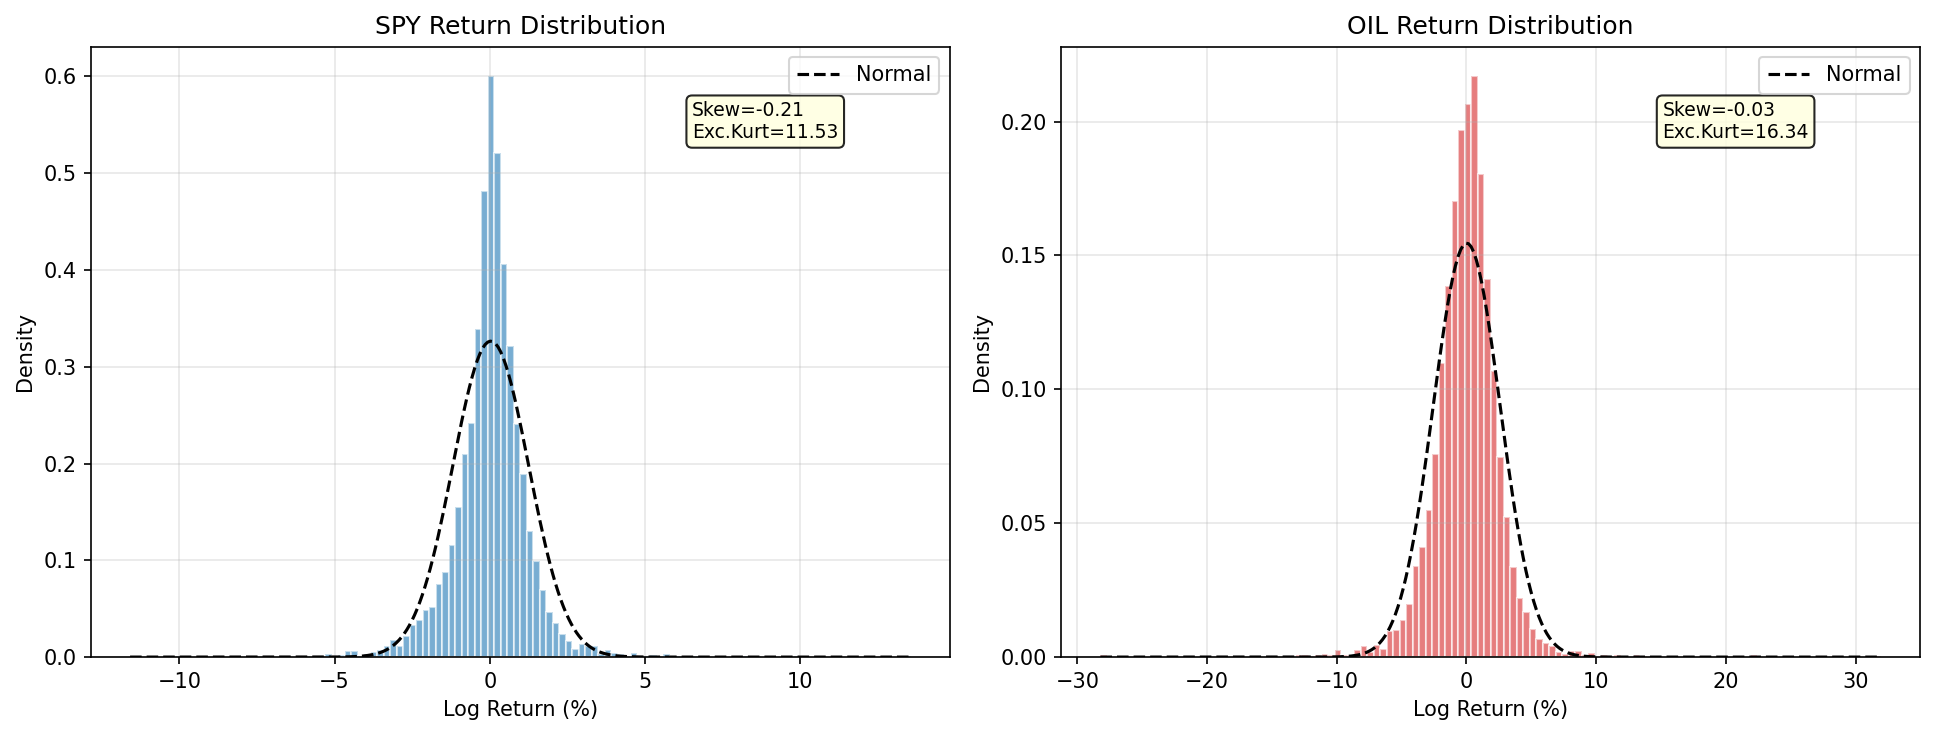

  fig8_SPY_OIL_Returns_distributions.png


In [125]:

# FIG3 distributions
fig,ax=plt.subplots(1,2,figsize=(13,5))
for a,r,nm,c in [(ax[0],spy_ret,"SPY","#1f77b4"),(ax[1],oil_ret,"OIL","#d62728")]:
    a.hist(r,bins=120,density=True,alpha=0.6,color=c,edgecolor="white",lw=0.3)
    x=np.linspace(r.min(),r.max(),300)
    a.plot(x,stats.norm.pdf(x,r.mean(),r.std()),"k--",lw=1.5,label="Normal")
    a.set_title(f"{nm} Return Distribution");a.set_xlabel("Log Return (%)");a.set_ylabel("Density")
    sk,ku=stats.skew(r),stats.kurtosis(r)
    a.annotate(f"Skew={sk:.2f}\nExc.Kurt={ku:.2f}",xy=(0.70,0.85),xycoords="axes fraction",fontsize=9,
               bbox=dict(boxstyle="round,pad=0.3",fc="lightyellow",alpha=0.85));a.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/fig8_SPY_OIL_Returns_distributions.png",bbox_inches="tight")#;plt.close()
plt.show()
print("  fig8_SPY_OIL_Returns_distributions.png")


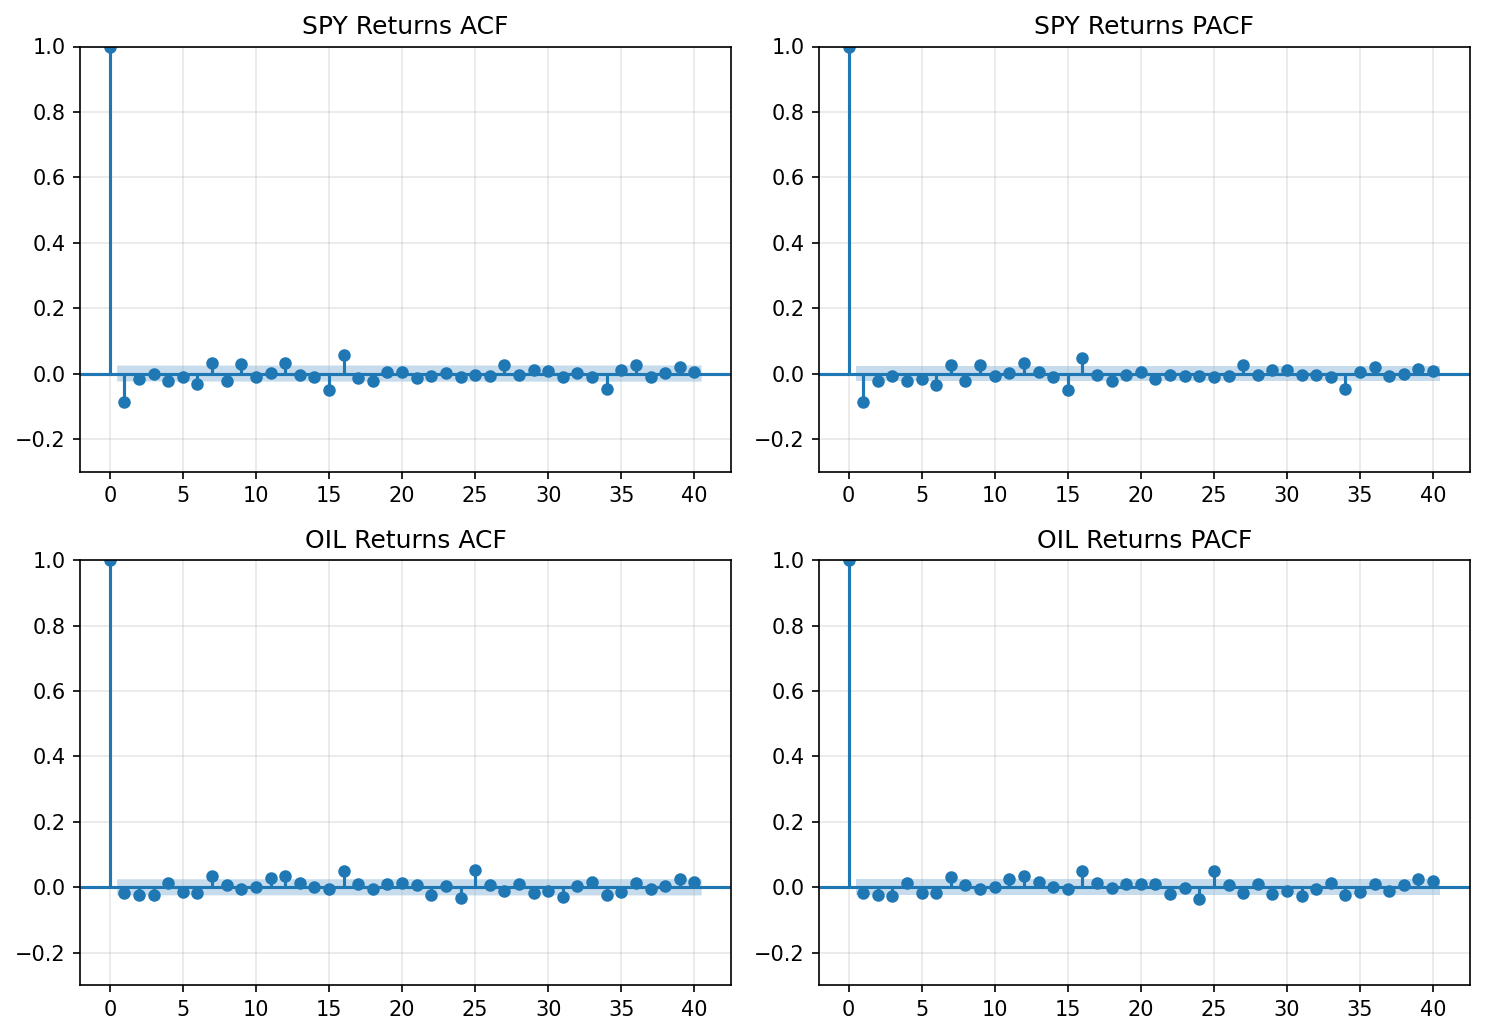

  fig9_SPY_OIL_returns_acf_pacf.png


In [129]:

# FIG5 ACF
fig,axes=plt.subplots(2,2,figsize=(10,7));nl=40
## ACF, PACF of returns only not squared returns
plot_acf(ax=axes[0,0], x=spy_ret, lags=nl, title="SPY Returns ACF")
plot_pacf(ax=axes[0,1], x=spy_ret, lags=nl, title="SPY Returns PACF")
plot_acf(ax=axes[1,0], x=oil_ret, lags=nl, title="OIL Returns ACF")
plot_pacf(ax=axes[1,1], x=oil_ret, lags=nl, title="OIL Returns PACF")
axes[0,0].set_ylim(-0.3,1.0); axes[0,1].set_ylim(-0.3,1.0)
axes[1,0].set_ylim(-0.3,1.0); axes[1,1].set_ylim(-0.3,1.0)
plt.tight_layout()
plt.savefig(f"{OUT}/fig9_SPY_OIL_returns_acf_pacf.png",bbox_inches="tight")#;plt.close()
plt.show()
print("  fig9_SPY_OIL_returns_acf_pacf.png")   


## 7. Annualized Volitility

In [ ]:
# ── 5. ROLLING VOL ──
spy_v22=spy_ret.rolling(22).std()*np.sqrt(252)
oil_v22=oil_ret.rolling(22).std()*np.sqrt(252)

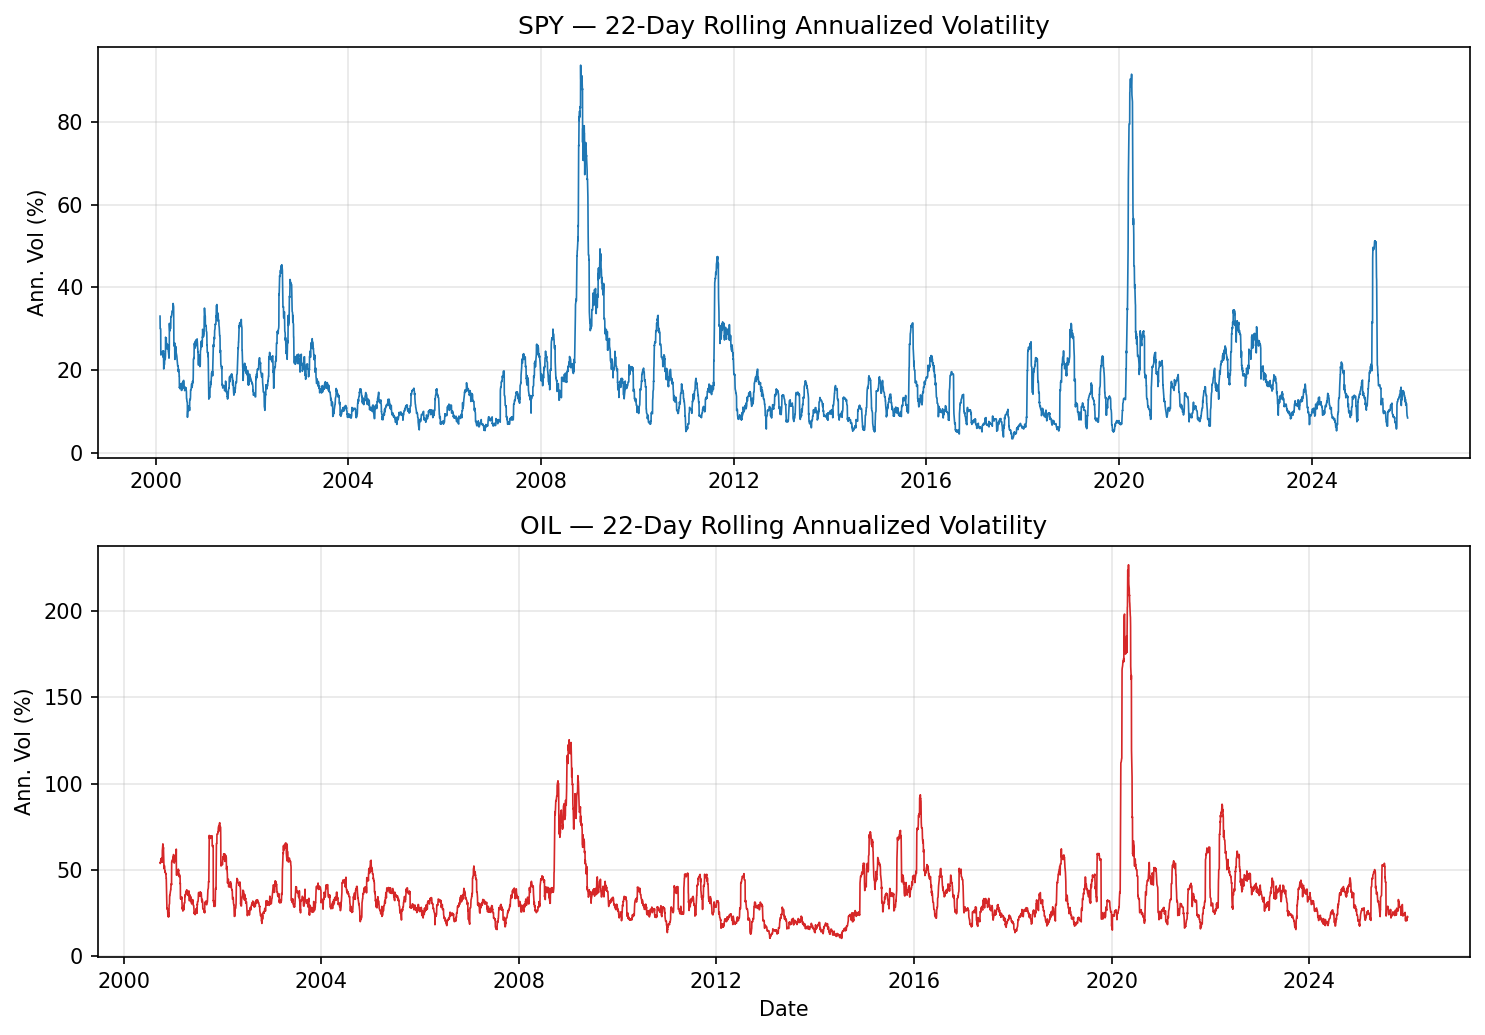

  fig10_SPY_OIL_rolling_volatility.png


In [128]:

# FIG6 rolling vol
fig,ax=plt.subplots(2,1,figsize=(10,7))
ax[0].plot(spy_v22.index,spy_v22.values,color="#1f77b4",lw=0.8)
ax[0].set_title("SPY — 22-Day Rolling Annualized Volatility");ax[0].set_ylabel("Ann. Vol (%)")
ax[1].plot(oil_v22.index,oil_v22.values,color="#d62728",lw=0.8)
ax[1].set_title("OIL — 22-Day Rolling Annualized Volatility");ax[1].set_ylabel("Ann. Vol (%)")
ax[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(f"{OUT}/fig10_SPY_OIL_rolling_volatility.png",bbox_inches="tight")#;plt.close()
plt.show()
print("  fig10_SPY_OIL_rolling_volatility.png")


## 8. SPY vs OIL Scatter Plot

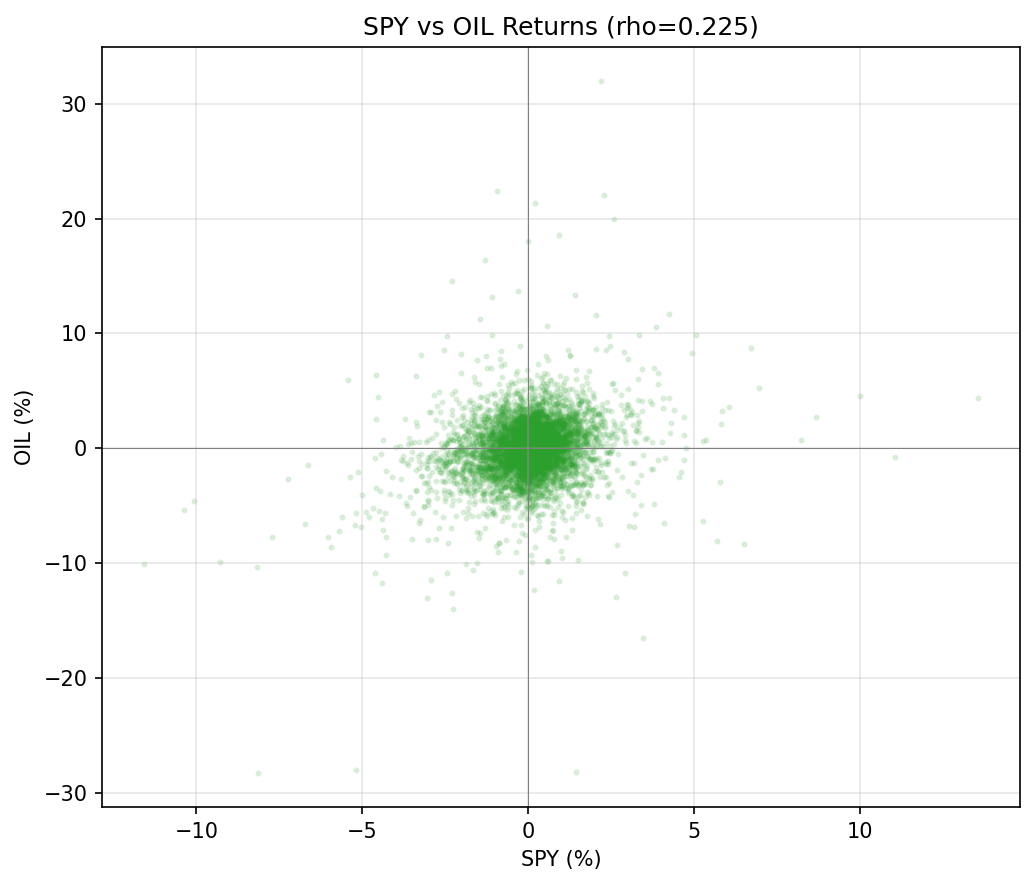

  fig11_scatter_SPY_vs_OIL.png


In [130]:

# FIG8 scatter + rolling corr
aligned=pd.DataFrame({"SPY":spy_ret,"OIL":oil_ret}).dropna()
rho=aligned["SPY"].corr(aligned["OIL"])
fig,a=plt.subplots(figsize=(7,6))
a.scatter(aligned["SPY"],aligned["OIL"],alpha=0.12,s=4,color="#2ca02c")
a.set_xlabel("SPY (%)");a.set_ylabel("OIL (%)");a.set_title(f"SPY vs OIL Returns (rho={rho:.3f})")
a.axhline(0,color="gray",lw=0.5);a.axvline(0,color="gray",lw=0.5)
plt.tight_layout()
plt.savefig(f"{OUT}/fig11_scatter_SPY_vs_OIL.png",bbox_inches="tight")#;plt.close()
plt.show()
print("  fig11_scatter_SPY_vs_OIL.png")


## 9. SPY vs OIL Rolling Correlation

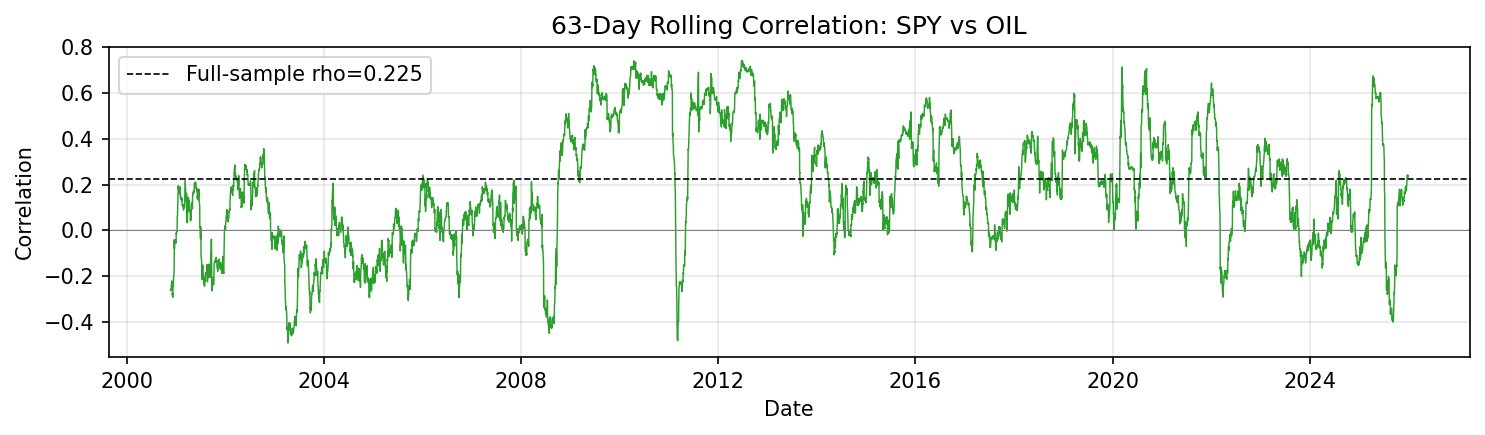

  fig9_rolling_corr.png


In [133]:

rc=aligned["SPY"].rolling(63).corr(aligned["OIL"])
fig,a=plt.subplots(figsize=(10,3))
a.plot(rc.index,rc.values,color="#2ca02c",lw=0.7)
a.axhline(rho,color="k",ls="--",lw=0.8,label=f"Full-sample rho={rho:.3f}")
a.axhline(0,color="gray",lw=0.5);a.set_title("63-Day Rolling Correlation: SPY vs OIL")
a.set_ylabel("Correlation");a.set_xlabel("Date");a.legend()
plt.tight_layout();plt.savefig(f"{OUT}/fig12_rolling_corr.png",bbox_inches="tight")#;plt.close()
plt.show()
print("  fig9_rolling_corr.png")
